# Maritime Tracker: Rich Telemetry LSTM Evaluation
This notebook performs a standardized evaluation of the Rich LSTM tracker. It calculates Mean IoU, AP@0.50, AP@0.75, MAE, and Centre-point RMSE, and displays the 3-panel evaluation dashboard.

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


### 1. Load Data & Extract Velocities
Load the sequence rich datasets and extract velocity vectors before scaling.

In [14]:
def extract_velocities(raw_sequences):
    """
    Converts raw coordinate sequences to (dx, dy, w, h, other_telem_dims).
    Output shape: (N, 10, 12)
    """
    N = raw_sequences.shape[0]
    velocity_seqs = np.zeros((N, 10, 12)) # 10 time-steps of history
    for i in range(10):
        curr = raw_sequences[:, i, :]
        nxt  = raw_sequences[:, i+1, :]
        dx = nxt[:, 0] - curr[:, 0]
        dy = nxt[:, 1] - curr[:, 1]
        w  = nxt[:, 2]
        h  = nxt[:, 3]
        telem = nxt[:, 4:]
        velocity_seqs[:, i, :] = np.column_stack((dx, dy, w, h, telem))
    return velocity_seqs

# File Paths
TRAIN_DATA_PATH = '../data/sequences_rich_train.npy'
TEST_DATA_PATH  = '../data/sequences_rich_test.npy'

if not os.path.exists(TRAIN_DATA_PATH):
    raise FileNotFoundError(f"Could not find data files! Make sure you have {TRAIN_DATA_PATH} present.")

print("Loading raw data...")
raw_train = np.load(TRAIN_DATA_PATH)
raw_test  = np.load(TEST_DATA_PATH)
print(f"Loaded Raw Train Shape: {raw_train.shape}")
print(f"Loaded Raw Test Shape:  {raw_test.shape}")

# Extract Velocities
train_data = extract_velocities(raw_train)
test_data  = extract_velocities(raw_test)

# Fit Scaler on Training Data
scaler = StandardScaler()
N_train, seq_len, features = train_data.shape
scaler.fit(train_data.reshape(-1, features))

# Scale Test Data
test_scaled_flat = scaler.transform(test_data.reshape(-1, features))
test_scaled = test_scaled_flat.reshape(test_data.shape[0], seq_len, features)
print(f"Scaled Test Data Shape: {test_scaled.shape}")


Loading raw data...
Loaded Raw Train Shape: (141737, 11, 12)
Loaded Raw Test Shape:  (15749, 11, 12)
Scaled Test Data Shape: (15749, 10, 12)


### 2. Define Model & Load Weights
Setup the Rich LSTM network architecture matching our trained checkpoints.

In [15]:
class RichLSTMTracker(nn.Module):
    def __init__(self, input_size=12, hidden_size=128, num_layers=2):
        super(RichLSTMTracker, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=False)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        return self.fc(last_time_step)

model = RichLSTMTracker().to(device)
model.eval()

weight_path = 'rich_lstm_tracker.pth'
if os.path.exists(weight_path):
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print(f"Successfully loaded LSTM weights from: {weight_path}")
    except Exception as e:
        print(f"Error loading state_dict: {e}")
else:
    print(f"WARNING: Weight file not found at: {weight_path}")


Successfully loaded LSTM weights from: rich_lstm_tracker.pth


### 3. Vectorized Inference
Predict future bounding box displacements across the whole test sequence in a fast, vectorized batch.

In [16]:
print("Running inference on test set...")
# CRITICAL: The LSTM was trained on length 9 to predict the 10th step!
X_test = torch.tensor(test_scaled[:, :-1, :], dtype=torch.float32).to(device)

with torch.no_grad():
    Y_pred_scaled = model(X_test).cpu().numpy()

Y_pred_padded = np.zeros((len(Y_pred_scaled), 12))
Y_pred_padded[:, :4] = Y_pred_scaled

Y_pred_vel = scaler.inverse_transform(Y_pred_padded)[:, :4]

# Decode predicted displacement velocities back into absolute box pixels
last_known_abs = raw_test[:, 9, :4]
true_target_abs = raw_test[:, 10, :4]

pred_target_abs = np.zeros_like(true_target_abs)
pred_target_abs[:, 0] = last_known_abs[:, 0] + Y_pred_vel[:, 0]
pred_target_abs[:, 1] = last_known_abs[:, 1] + Y_pred_vel[:, 1]
pred_target_abs[:, 2] = Y_pred_vel[:, 2]
pred_target_abs[:, 3] = Y_pred_vel[:, 3]

print("Predictions decoded successfully.")


Running inference on test set...
Predictions decoded successfully.


### 4. Calculate Performance Metrics
Evaluate Mean IoU, precision thresholds (AP@50, AP@75), Absolute Center Error, and Root Mean Square Errors.

In [17]:
def iou_xywh(b1, b2):
    x1 = max(b1[0], b2[0]);  y1 = max(b1[1], b2[1])
    x2 = min(b1[0]+b1[2], b2[0]+b2[2])
    y2 = min(b1[1]+b1[3], b2[1]+b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter / max(union, 1e-6)

all_iou = []
all_mae_x = []
all_mae_y = []
all_rmse_vals = []

for i in range(len(true_target_abs)):
    pred_box = pred_target_abs[i]
    gt_box = true_target_abs[i]
    
    iou_val = iou_xywh(pred_box, gt_box)
    all_iou.append(iou_val)
    
    pred_cx, pred_cy = pred_box[0] + pred_box[2]/2, pred_box[1] + pred_box[3]/2
    gt_cx,   gt_cy   = gt_box[0] + gt_box[2]/2,     gt_box[1] + gt_box[3]/2
    
    all_mae_x.append(abs(pred_cx - gt_cx))
    all_mae_y.append(abs(pred_cy - gt_cy))
    all_rmse_vals.append((pred_cx - gt_cx)**2 + (pred_cy - gt_cy)**2)

all_iou = np.array(all_iou)
all_mae_x = np.array(all_mae_x)
all_mae_y = np.array(all_mae_y)
all_rmse_vals = np.array(all_rmse_vals)

mean_iou = all_iou.mean()
iou50 = (all_iou >= 0.50).mean() * 100
iou75 = (all_iou >= 0.75).mean() * 100
mae_x = all_mae_x.mean()
mae_y = all_mae_y.mean()
rmse_c = np.sqrt(all_rmse_vals.mean())

print("=" * 55)
print(f"  Evaluation on {len(raw_test):,} test sequences")
print("=" * 55)
print(f"  Mean IoU                : {mean_iou:.4f}")
print(f"  mAP @ IoU 0.50 (%)      : {iou50:.2f}%")
print(f"  mAP @ IoU 0.75 (%)      : {iou75:.2f}%")
print(f"  MAE x-center (px)       : {mae_x:.2f}")
print(f"  MAE y-center (px)       : {mae_y:.2f}")
print(f"  Centre-point RMSE (px)  : {rmse_c:.2f}")
print("=" * 55)


  Evaluation on 15,749 test sequences
  Mean IoU                : 0.9148
  mAP @ IoU 0.50 (%)      : 99.54%
  mAP @ IoU 0.75 (%)      : 95.45%
  MAE x-center (px)       : 1.76
  MAE y-center (px)       : 1.38
  Centre-point RMSE (px)  : 3.88


### 5. Render Evaluation Dashboard
Plot the 3-panel high-fidelity evaluation dashboard including IoU distribution, center-point pixel errors, and 2D sample trajectories.

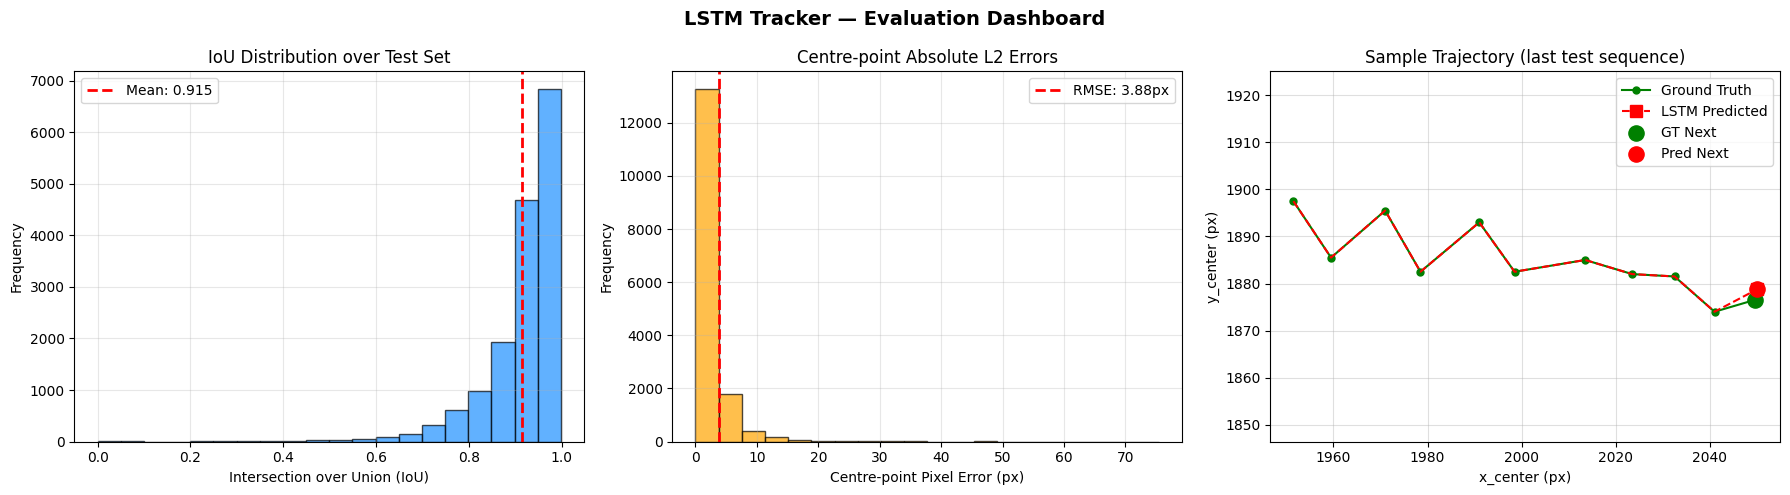


Saved evaluation figure -> lstm_evaluation.png

Ground Truth next box : [1940.0, 1615.0, 219.0, 523.0]
Predicted next box    : [np.float64(1939.98), np.float64(1616.98), np.float64(220.0), np.float64(523.51)]


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Subplot 1: IoU Distribution ──────────────────────────────────────────────
axes[0].hist(all_iou, bins=20, color='dodgerblue', edgecolor='black', alpha=0.7)
axes[0].axvline(mean_iou, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_iou:.3f}')
axes[0].set_xlabel('Intersection over Union (IoU)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('IoU Distribution over Test Set')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Subplot 2: Centre-Point Error Histogram ───────────────────────────────────
center_errors = np.sqrt(all_rmse_vals)
axes[1].hist(center_errors, bins=20, color='orange', edgecolor='black', alpha=0.7)
axes[1].axvline(rmse_c, color='red', linestyle='--', linewidth=2, label=f'RMSE: {rmse_c:.2f}px')
axes[1].set_xlabel('Centre-point Pixel Error (px)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Centre-point Absolute L2 Errors')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Subplot 3: Trajectory Visualisation ─────────────────────────────────────
sample_raw = raw_test[-3] # Grab the last test sequence
inp_hist = extract_velocities(sample_raw[np.newaxis])[0]

scaled_inp_hist = scaler.transform(inp_hist)
# CRITICAL: Pass first 9 steps of scaled history to the LSTM
seq = torch.tensor(scaled_inp_hist[:-1, :], dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    pred_scaled = model(seq).cpu().numpy()
    
pred_padded = np.zeros((1, 12))
pred_padded[0, :4] = pred_scaled
pred_vel = scaler.inverse_transform(pred_padded)[0][:4]

last_abs = sample_raw[9, :4]
pred_box = [last_abs[0]+pred_vel[0], last_abs[1]+pred_vel[1], pred_vel[2], pred_vel[3]]
gt_next = sample_raw[10, :4].tolist()
history_boxes = [sample_raw[i, :4].tolist() for i in range(10)]

xs_gt   = [b[0]+b[2]/2 for b in history_boxes] + [gt_next[0]+gt_next[2]/2]
ys_gt   = [b[1]+b[3]/2 for b in history_boxes] + [gt_next[1]+gt_next[3]/2]
xs_pred = [b[0]+b[2]/2 for b in history_boxes] + [pred_box[0]+pred_box[2]/2]
ys_pred = [b[1]+b[3]/2 for b in history_boxes] + [pred_box[1]+pred_box[3]/2]

axes[2].plot(xs_gt,   ys_gt,   'g-o',  label='Ground Truth',  markersize=5)
axes[2].plot(xs_pred, ys_pred, 'r--s', label='LSTM Predicted', markersize=8, markevery=[-1])
axes[2].scatter(xs_gt[-1],   ys_gt[-1],   color='green', s=120, zorder=5, label='GT Next')
axes[2].scatter(xs_pred[-1], ys_pred[-1], color='red',   s=120, zorder=5, label='Pred Next')
axes[2].set_xlabel('x_center (px)'); axes[2].set_ylabel('y_center (px)')
axes[2].set_title('Sample Trajectory (last test sequence)')
axes[2].legend(); axes[2].grid(True, alpha=0.4)

# Force axes to have reasonable ranges to prevent Matplotlib from zooming to sub-pixels
x_min, x_max = axes[2].get_xlim()
y_min, y_max = axes[2].get_ylim()
if abs(x_max - x_min) < 30:
    center_x = (x_max + x_min) / 2
    axes[2].set_xlim(center_x - 15, center_x + 15)
if abs(y_max - y_min) < 30:
    center_y = (y_max + y_min) / 2
    axes[2].set_ylim(center_y - 15, center_y + 15)
axes[2].axis('equal')

plt.suptitle('LSTM Tracker — Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_evaluation.png', dpi=150)
plt.show()

print(f"\nSaved evaluation figure -> lstm_evaluation.png")
print(f"\nGround Truth next box : {[round(v,2) for v in gt_next]}")
print(f"Predicted next box    : {[round(v,2) for v in pred_box]}")
